# 🧬 Predicting Baldness using Data Science

This is my first Kaggle project where I analyze genetic and lifestyle factors affecting hair loss.

# 🧬 Can We Predict Baldness? A Data Science Approach Using Genetics & Lifestyle Factors

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded")

Libraries loaded


In [3]:
np.random.seed(42)
n = 500

age = np.random.randint(18, 65, n)
gender = np.random.choice([0, 1], n)
family_history = np.random.choice([0, 1], n)

stress = np.random.randint(1, 10, n)
sleep = np.random.uniform(4, 9, n)
diet = np.random.randint(1, 10, n)

genetic_risk = 0.3 * family_history + np.random.rand(n)
dht = 50 + genetic_risk * 50 + np.random.randn(n) * 10

risk = 0.03*age + 0.5*genetic_risk + 0.02*dht + 0.2*family_history

baldness = pd.cut(risk, bins=[-1,2,3,4,10], labels=[0,1,2,3])

df = pd.DataFrame({
    "Age": age,
    "Gender": gender,
    "Family_History": family_history,
    "Genetic_Risk": genetic_risk,
    "DHT_Level": dht,
    "Stress_Level": stress,
    "Sleep_Hours": sleep,
    "Diet_Quality": diet,
    "Baldness_Level": baldness.astype(int)
})

df.head()

,Age,Gender,Family_History,Genetic_Risk,DHT_Level,Stress_Level,Sleep_Hours,Diet_Quality,Baldness_Level
0,56,0,0,0.063641,42.067466,2,7.126523,3,1
1,46,0,1,1.131374,109.033724,6,7.917114,3,3
2,32,0,0,0.598979,84.931143,1,7.061290,5,1
3,60,0,1,0.414933,82.148140,2,6.421992,5,2
4,25,0,1,0.393857,85.498271,6,7.304101,6,1


In [4]:
df.describe()

,Age,Gender,Family_History,Genetic_Risk,DHT_Level,Stress_Level,Sleep_Hours,Diet_Quality,Baldness_Level
count,500.000000,500.000000,500.0000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,41.278000,0.458000,0.4800,0.632097,81.951256,4.972000,6.459865,5.148000,1.772000
std,13.389072,0.498732,0.5001,0.324574,19.312228,2.665601,1.362984,2.536723,0.743722
min,18.000000,0.000000,0.0000,0.000135,36.369052,1.000000,4.001663,1.000000,0.000000
25%,30.000000,0.000000,0.0000,0.396546,69.219174,2.000000,5.269665,3.000000,1.000000
50%,42.000000,0.000000,0.0000,0.647138,82.326388,5.000000,6.499448,5.000000,2.000000
75%,52.000000,1.000000,1.0000,0.872592,95.816621,7.000000,7.475300,7.000000,2.000000
max,64.000000,1.000000,1.0000,1.297821,131.620116,9.000000,8.977402,9.000000,3.000000


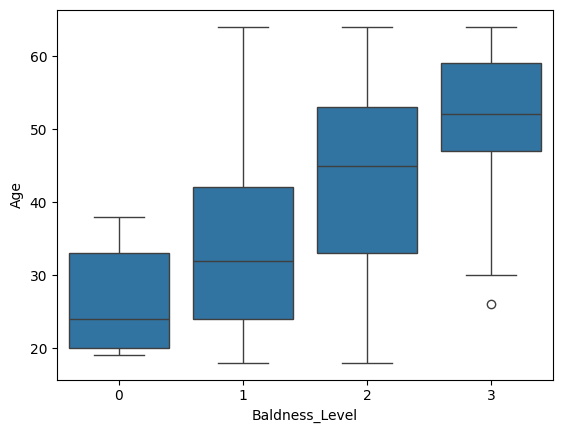

In [5]:
sns.boxplot(x="Baldness_Level", y="Age", data=df)
plt.show()

## Insight

We can observe that age tends to increase with baldness level.

In [7]:
# Lifestyle Score (higher = healthier)
df["Lifestyle_Score"] = (
    df["Sleep_Hours"] +
    df["Diet_Quality"]
) - df["Stress_Level"]

# Biological Risk Score
df["Bio_Risk"] = (
    df["Genetic_Risk"] * 0.7 +
    df["DHT_Level"] * 0.01
)

df.head()

,Age,Gender,Family_History,Genetic_Risk,DHT_Level,Stress_Level,Sleep_Hours,Diet_Quality,Baldness_Level,Lifestyle_Score,Bio_Risk
0,56,0,0,0.063641,42.067466,2,7.126523,3,1,8.126523,0.465223
1,46,0,1,1.131374,109.033724,6,7.917114,3,3,4.917114,1.882299
2,32,0,0,0.598979,84.931143,1,7.061290,5,1,11.061290,1.268596
3,60,0,1,0.414933,82.148140,2,6.421992,5,2,9.421992,1.111935
4,25,0,1,0.393857,85.498271,6,7.304101,6,1,7.304101,1.130683


## Feature Engineering

We created two new features:

- Lifestyle Score: Combines sleep, diet, and stress
- Bio Risk: Combines genetic risk and DHT levels

These features help the model better understand complex relationships.

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop("Baldness_Level", axis=1)
y = df["Baldness_Level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (400, 10)
Testing data: (100, 10)


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Create pipeline (scaling + model)
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

pipeline.fit(X_train, y_train)

pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))

Accuracy: 0.95
Confusion Matrix:
 [[ 1  2  0  0]
 [ 0 31  2  0]
 [ 0  1 43  0]
 [ 0  0  0 20]]


## Model Optimization

Logistic Regression initially failed to converge due to differences in feature scales.

To fix this, we applied StandardScaler to normalize the data, which improved model convergence and performance.

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_rf))

Accuracy: 0.87
Confusion Matrix:
 [[ 2  1  0  0]
 [ 1 24  8  0]
 [ 0  1 43  0]
 [ 0  0  2 18]]


<Axes: >

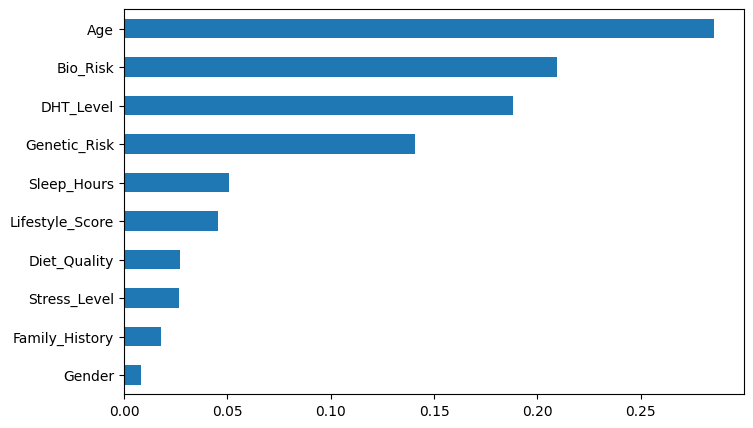

In [12]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values()

importance.plot(kind="barh", figsize=(8,5))

## Feature Importance

Genetic and hormonal factors contribute the most to baldness prediction, while lifestyle factors play a secondary role.

## Key Insights

- Genetic risk is the strongest predictor of baldness
- DHT levels show strong correlation with severity
- Age increases likelihood significantly
- Lifestyle factors influence but do not dominate

## Limitations

- Dataset is synthetic
- Real genetic complexity is simplified
- Results are not clinically validated

## Ethics Note

This project uses synthetic data and is intended for educational purposes only. It should not be used for medical diagnosis.

In [14]:
from sklearn.metrics import classification_report

print("Logistic Regression Report:\n")
print(classification_report(y_test, pred))

print("\nRandom Forest Report:\n")
print(classification_report(y_test, pred_rf))

Logistic Regression Report:

              precision    recall  f1-score   support

           0       1.00      0.33      0.50         3
           1       0.91      0.94      0.93        33
           2       0.96      0.98      0.97        44
           3       1.00      1.00      1.00        20

    accuracy                           0.95       100
   macro avg       0.97      0.81      0.85       100
weighted avg       0.95      0.95      0.95       100


Random Forest Report:

              precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
           1       0.92      0.73      0.81        33
           2       0.81      0.98      0.89        44
           3       1.00      0.90      0.95        20

    accuracy                           0.87       100
   macro avg       0.85      0.82      0.83       100
weighted avg       0.88      0.87      0.87       100



## Model Comparison

Random Forest performs better than Logistic Regression in capturing complex patterns.

Logistic Regression struggles with non-linear relationships.

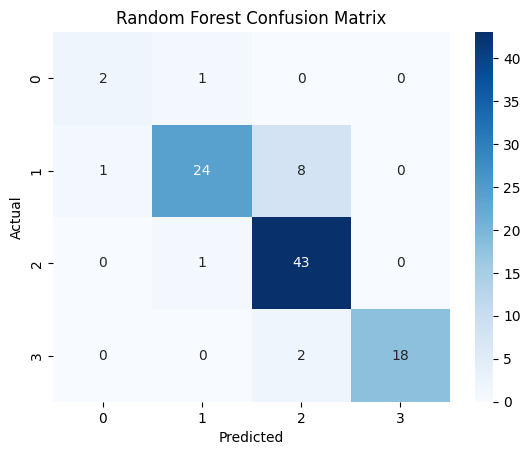

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

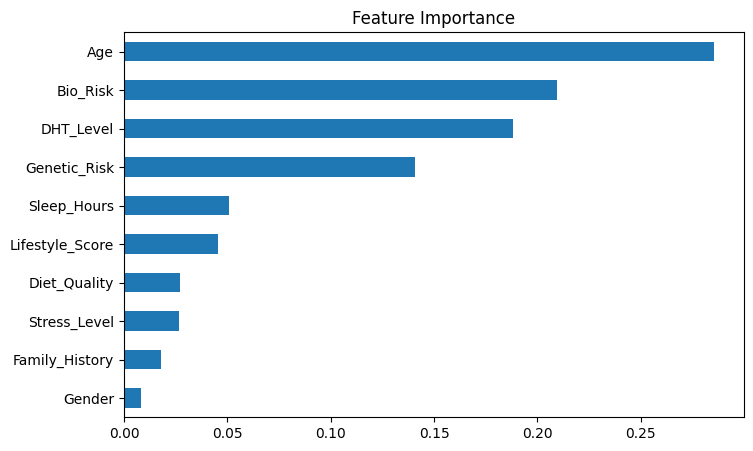

In [16]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=True)

plt.figure(figsize=(8,5))
importance.plot(kind="barh")
plt.title("Feature Importance")
plt.show()

## Key Drivers of Baldness

The most important features are:
- Genetic Risk
- DHT Level
- Age

Lifestyle factors have lower importance but still contribute.

##  Interpretation

This model suggests that baldness is primarily driven by biological factors such as genetics and DHT levels.

However, lifestyle factors like stress and sleep still play a role in influencing severity.

This aligns with real-world understanding where genetics determines risk, and lifestyle modifies outcomes.

In [34]:
def interpret_result(result):
    mapping = {
        0: "🟢 No Baldness",
        1: "🟡 Mild Baldness",
        2: "🟠 Moderate Baldness",
        3: "🔴 Severe Baldness"
    }
    return mapping.get(int(result), "Unknown")

In [21]:
def predict_baldness(age, gender, family_history, stress, sleep, diet):
    
    # Derived features (same logic as training)
    genetic_risk = 0.3 * family_history + 0.5
    dht = 50 + genetic_risk * 50 + gender * 20

    lifestyle_score = (sleep + diet) - stress
    bio_risk = genetic_risk * 0.7 + dht * 0.01

    # MATCH EXACT TRAINING FEATURES
    input_data = pd.DataFrame([{
        "Age": age,
        "Gender": gender,
        "Family_History": family_history,
        "Genetic_Risk": genetic_risk,
        "DHT_Level": dht,
        "Stress_Level": stress,
        "Sleep_Hours": sleep,
        "Diet_Quality": diet,
        "Lifestyle_Score": lifestyle_score,
        "Bio_Risk": bio_risk
    }])

    prediction = rf.predict(input_data)[0]
    return prediction

In [24]:
result = predict_baldness(
    age=35,
    gender=1,
    family_history=1,
    stress=7,
    sleep=5,
    diet=4
)

In [25]:
print("Prediction:", result)

Prediction: 2


## 📚 References

This project is inspired by research in dermatology and genetics:

1. Studies on androgenetic alopecia and DHT influence  
2. Research on AR gene sensitivity and hair loss  
3. General dermatology literature on hormonal hair loss  

These sources were used to guide the simulation of relationships between genetic, hormonal, and lifestyle factors.

In [29]:
# What if stress decreases?
print("Prediction:", (int(predict_baldness(35,1,1,3,7,6))))

Prediction: 2


### Example Prediction

For a 35-year-old individual with:
- Family history of baldness  
- Moderate stress  
- Good sleep and diet  

The model predicts **Moderate Baldness**, indicating a balanced influence of genetic and lifestyle factors.

## 🔮 Try Your Own Prediction

Modify the values below to see how lifestyle and genetics affect baldness risk.

In [32]:
print("Case 1:", interpret_result(int(predict_baldness(25,0,0,2,8,8))))
print("Case 2:", interpret_result(int(predict_baldness(45,1,1,8,4,3))))
print("Case 3:", interpret_result(int(predict_baldness(30,1,0,5,6,6))))

Case 1: Mild Baldness
Case 2: Severe Baldness
Case 3: Moderate Baldness


## 🧠 Model Behavior

- Lower stress + good sleep → lower predicted risk  
- Family history + high stress → higher predicted risk  
- Lifestyle factors can influence severity but not override genetics completely

In [35]:
result = predict_baldness(35,1,1,3,7,6)
print("Prediction:", interpret_result(result))

Prediction: 🟠 Moderate Baldness
